Instrucciones

1. Continuar desde la Parte IV
* Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.
2. Exploración de Datos Avanzada
* Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.
* Crea subplots para comparar diferentes variables clave.
* Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.

Se carga el Dataset limpio de Proyecto I - Parte IV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/retail_sales_dataset_limpio1.csv')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Tax Amount,Final Price,Sales Normalized,Sales Category,Transaction Rating
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,28.5,178.5,0.063291,Medium,Underperforming❌
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,190.0,1190.0,0.493671,High,Outperforming🔥
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,5.7,35.7,0.002532,Low,Underperforming❌
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,95.0,595.0,0.240506,Medium,Outperforming🔥
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,19.0,119.0,0.037975,Medium,Underperforming❌
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,9.5,59.5,0.012658,Low,Underperforming❌
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,17.1,107.1,0.032911,Medium,Underperforming❌
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,19.0,119.0,0.037975,Medium,Underperforming❌
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,28.5,178.5,0.063291,Medium,Underperforming❌


EDA

Heatmap

In [ ]:
# Paso 1: calcular la correlación
cols_num = ["Age", "Quantity", "Price per Unit", "Total Amount"]
corr = df[cols_num].corr()

print("Matriz de correlación:")
display(corr.round(2))

Matriz de correlación:


,Age,Quantity,Price per Unit,Total Amount
Age,1.00,-0.02,-0.04,-0.06
Quantity,-0.02,1.00,0.02,0.37
Price per Unit,-0.04,0.02,1.00,0.85
Total Amount,-0.06,0.37,0.85,1.00


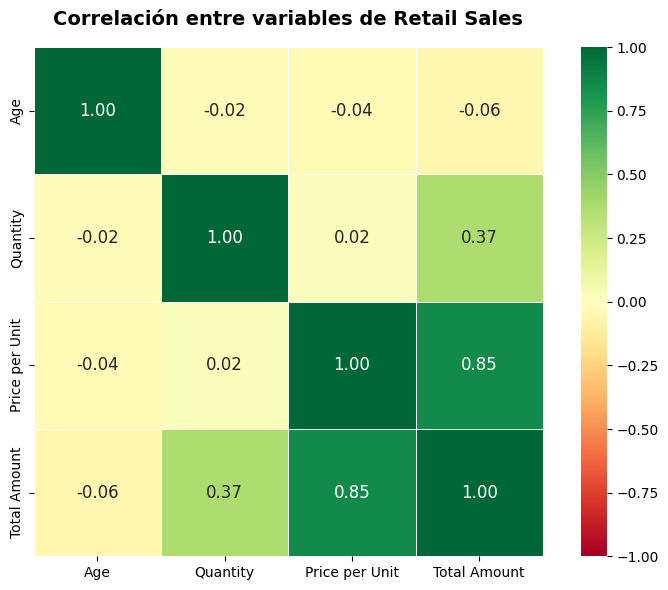

In [ ]:
# Paso 2: dibujarla con heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,          # muestra el número dentro de cada celda
    fmt=".2f",           # formato del número
    cmap="RdYlGn",       # rojo=negativo, verde=positivo
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 12},
    ax=ax
)

ax.set_title("Correlación entre variables de Retail Sales", fontsize=14, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

Se aprecia una correlación positiva muy fuerte entre 'Price per Unit' y 'Total Amount', lo cual es lógico. Por otro lado, respecto a la edad la correlación es prácticamente cercana  a cero. Esto permite confirmar que no existe un sesgo de edad. Una persona de 20 años y 60 años tienen el mismo potencial de compra para las ventas de este dataset. Esto significa que las campañas de marketing deben ser transversales y no segmentadas por edad ya que el interés por los productos es uniforme.

Subplots comparativos

/tmp/ipykernel_40528/3412423881.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product Category', y='Total Amount', ax=axes[1], palette='viridis')


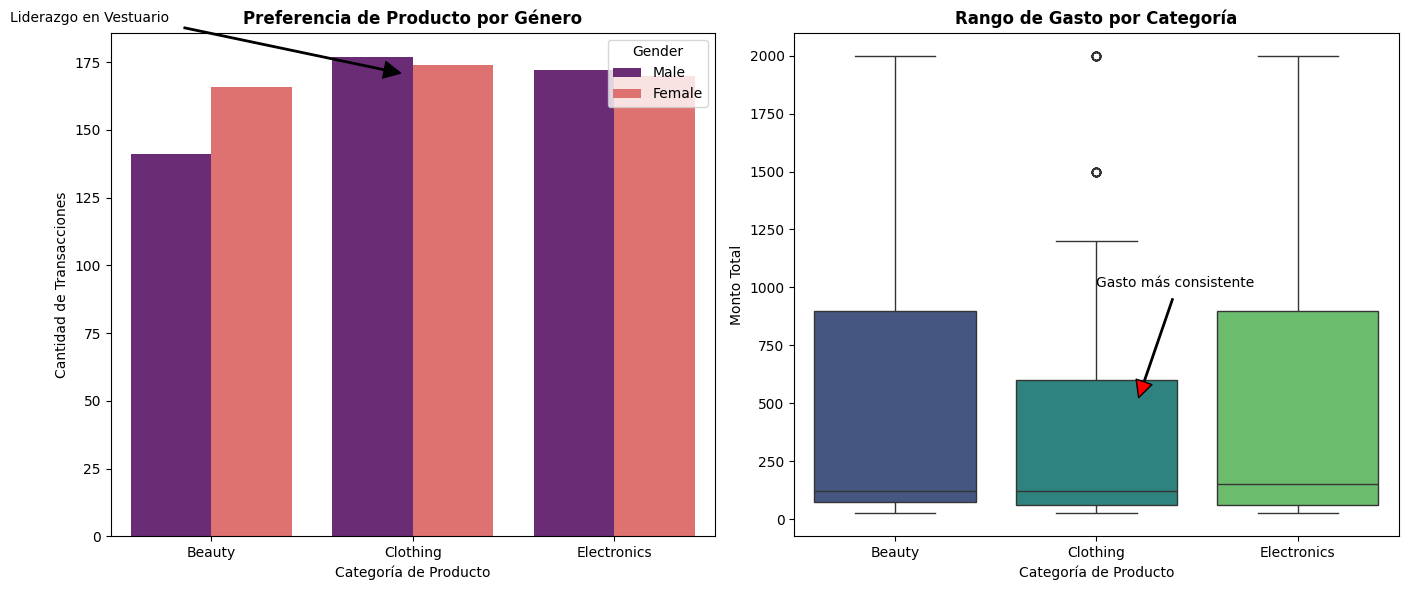

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico A: Ventas por Categoría y Género
sns.countplot(data=df, x='Product Category', hue='Gender', ax=axes[0], palette='magma')
axes[0].set_title("Preferencia de Producto por Género", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Categoría de Producto")
axes[0].set_ylabel("Cantidad de Transacciones")
axes[0].annotate('Liderazgo en Vestuario', xy=(1, 170), xytext=(-1, 190),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# Gráfico B: Distribución de Gasto por Categoría
sns.boxplot(data=df, x='Product Category', y='Total Amount', ax=axes[1], palette='viridis')
axes[1].set_title("Rango de Gasto por Categoría", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Categoría de Producto")
axes[1].set_ylabel("Monto Total")
axes[1].annotate('Gasto más consistente', xy=(1.2, 500), xytext=(1.0, 1000),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

En el primer gráfico se aprecia que la categoría de belleza es la única que muestra una brecha marcada de género, liderada por público femenino. Por el contrario, la parte de electrónica tiene paridad casi absoluta lo que indica que es una categoría de interés universal para nuestra base de clientes.

En el gráfico de Boxplot se señala que de las 3 categorías de producto, Vestimenta tiene una amplitud de caja menor respecto al resto, por lo que su rango de precios es menos volátil. Además, presenta 2 puntos Outliers: compras inusualmente caras según se comporta normalmente esta categoría, rompiendo la tendencia habitual

A modo de conclusión, la categoría de belleza debe mantener el marketing enfocado en mujeres, pero no se puede descuidar al público masculino: si bien compran menos seguido, cuando lo hacen desembolsan un poco más.